<a href="https://colab.research.google.com/github/Vinz602/NeuralNetworkFromScratch/blob/main/nn_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [64]:
import numpy as np

## Make Data

In [65]:
def make_moons(n_samples=300, noise=0.15):
    n = n_samples // 2
    theta1 = np.linspace(0, np.pi, n)
    x1 = np.stack([np.cos(theta1), np.sin(theta1)], axis=1)
    theta2 = np.linspace(0, np.pi, n)
    x2 = np.stack([1 - np.cos(theta2), 1 - np.sin(theta2) - 0.5], axis=1)
    X = np.vstack([x1, x2])
    y = np.hstack([np.zeros(n), np.ones(n)]).reshape(-1, 1)
    X += np.random.normal(scale=noise, size=X.shape)
    return X, y

X, y = make_moons(n_samples=300, noise=0.15)

In [66]:
def relu(z):
  return np.maximum(0,z)

def sigmoid(z):
  return 1.0 / (1.0 + np.exp(-z))

def softmax(z):
  return np.exp(z) / np.sum(np.exp(z), axis=1, keepdims=True)

def forward_prop(X, W1, b1, W2, b2):
  Z1 = X @ W1 + b1
  A1 = relu(Z1)
  Z2 = A1 @ W2 + b2
  A2 = sigmoid(Z2) #Because there is only two classes
  return A2, (X, Z1, A1, Z2, A2)

def binary_crossentopy(A2, y, eps=1e-8):
  return -np.mean(y * np.log(A2 + eps) + (1 - y) * np.log(1 - A2 + eps))

def backward_prop(cache, y, W2):
  X, Z1, A1, Z2, A2 = cache
  N = y.shape[0]
  dZ2 = (A2 - y) / N
  dW2 = A1.T @ dZ2
  db2 = np.sum(dZ2, axis=0, keepdims=True)
  dA1 = dZ2 @ W2.T
  dZ1 = dA1 * (Z1 > 0)
  dW1 = X.T @ dZ1
  db1 = np.sum(dZ1, axis=0, keepdims=True)
  return dW1, db1, dW2, db2

In [67]:
W1 = np.random.randn(2, 4) * np.sqrt(2.0 / 2)
b1 = np.zeros((1, 4))
W2 = np.random.randn(4, 1) * np.sqrt(2.0 / 4)
b2 = np.zeros((1, 1))

In [68]:
lr, epochs = 0.5, 5000
for epoch in range(epochs):
    A2, cache = forward_prop(X, W1, b1, W2, b2)
    dW1, db1, dW2, db2 = backward_prop(cache, y, W2)
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2

## Plotting

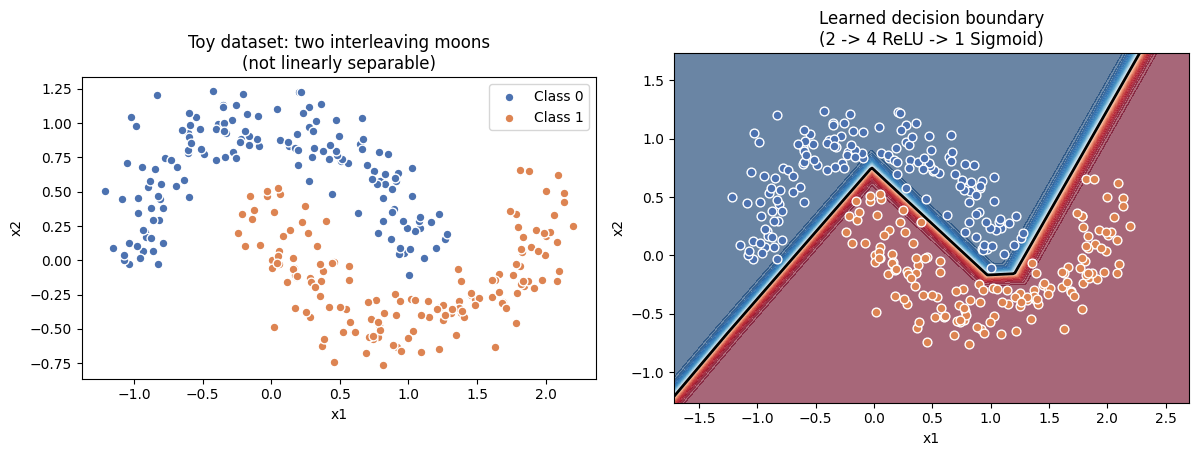

In [69]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: raw dataset
ax = axes[0]
ax.scatter(X[y.ravel() == 0, 0], X[y.ravel() == 0, 1],
           c="#4C72B0", label="Class 0", edgecolors="white", s=40)
ax.scatter(X[y.ravel() == 1, 0], X[y.ravel() == 1, 1],
           c="#DD8452", label="Class 1", edgecolors="white", s=40)
ax.set_title("Toy dataset: two interleaving moons\n(not linearly separable)")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.legend()
ax.set_aspect("equal")

# Right: learned decision boundary
ax = axes[1]
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                      np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
probs, _ = forward_prop(grid, W1, b1, W2, b2)
probs = probs.reshape(xx.shape)

ax.contourf(xx, yy, probs, levels=50, cmap="RdBu_r", alpha=0.6)
ax.contour(xx, yy, probs, levels=[0.5], colors="black", linewidths=2)
ax.scatter(X[y.ravel() == 0, 0], X[y.ravel() == 0, 1],
           c="#4C72B0", edgecolors="white", s=40)
ax.scatter(X[y.ravel() == 1, 0], X[y.ravel() == 1, 1],
           c="#DD8452", edgecolors="white", s=40)
ax.set_title("Learned decision boundary\n(2 -> 4 ReLU -> 1 Sigmoid)")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_aspect("equal")

plt.tight_layout()
